## 移动平均策略

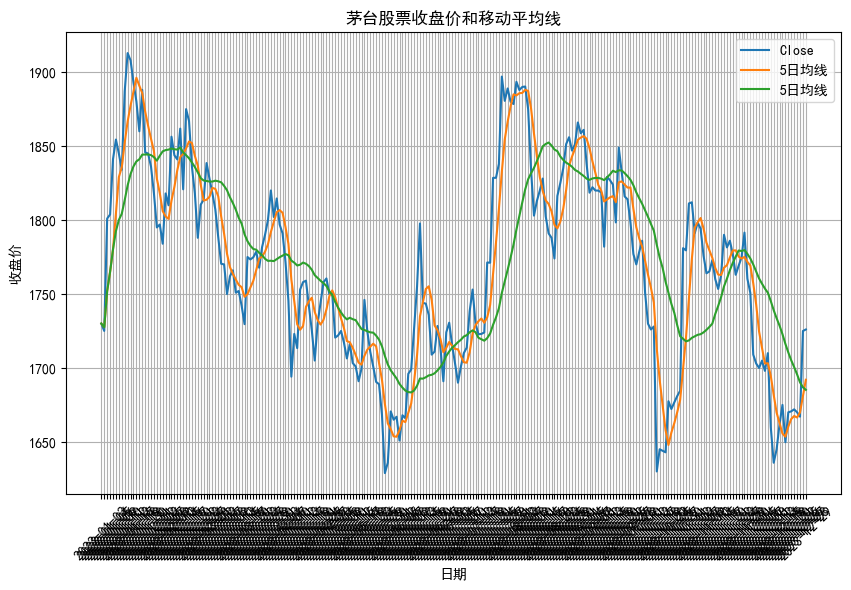

In [1]:
#1加载数据
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance  as mpf
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
df = pd.read_csv('C:/Users/86157/Desktop/茅台2023年股价.csv')
# 修改列名
df.columns = ['Date','Open', 'High', 'Low', 'Close','Volume','Amount'] 
#计算均线
df['MA5'] = df['Close'].rolling(window=5,min_periods=1).mean()
df['MA20'] = df['Close'].rolling(window=20,min_periods=1).mean()
#绘图
plt.figure(figsize=(10,6))
plt.plot(df['Date'],df['Close'],label='Close')
plt.plot(df['Date'],df['MA5'],label='5日均线')
plt.plot(df['Date'],df['MA20'],label='5日均线')
plt.xlabel('日期')
plt.ylabel('收盘价')
plt.title('茅台股票收盘价和移动平均线')
plt.legend()
plt.xticks(rotation =45 )
plt.grid(True)
plt.show()

## 绘制K线图

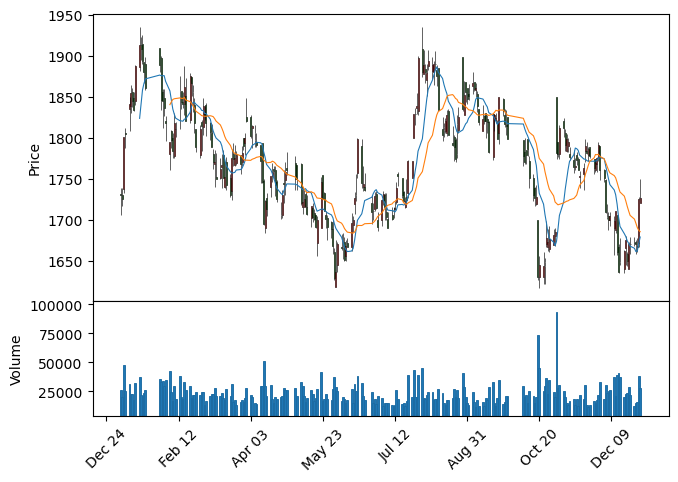

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance  as mpf
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
df = pd.read_csv('C:/Users/86157/Desktop/茅台2023年股价.csv')
# 修改列名
df.columns = ['Date','Open', 'High', 'Low', 'Close','Volume','Amount'] 
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)
market_colors = mpf.make_marketcolors(up='red',down='green')
my_style = mpf.make_mpf_style(marketcolors = market_colors)
#绘图
mpf.plot(df,type = 'candle',mav=(10,20),volume=True,show_nontrading = True,style=my_style)

## 合并俩个图表

In [19]:
df

Date
2023-01-03    1730.01
2023-01-04    1725.01
2023-01-05    1801.00
2023-01-06    1803.77
2023-01-09    1841.20
               ...   
2023-12-25    1672.00
2023-12-26    1670.00
2023-12-27    1667.06
2023-12-28    1724.99
2023-12-29    1726.00
Name: Close, Length: 242, dtype: float64

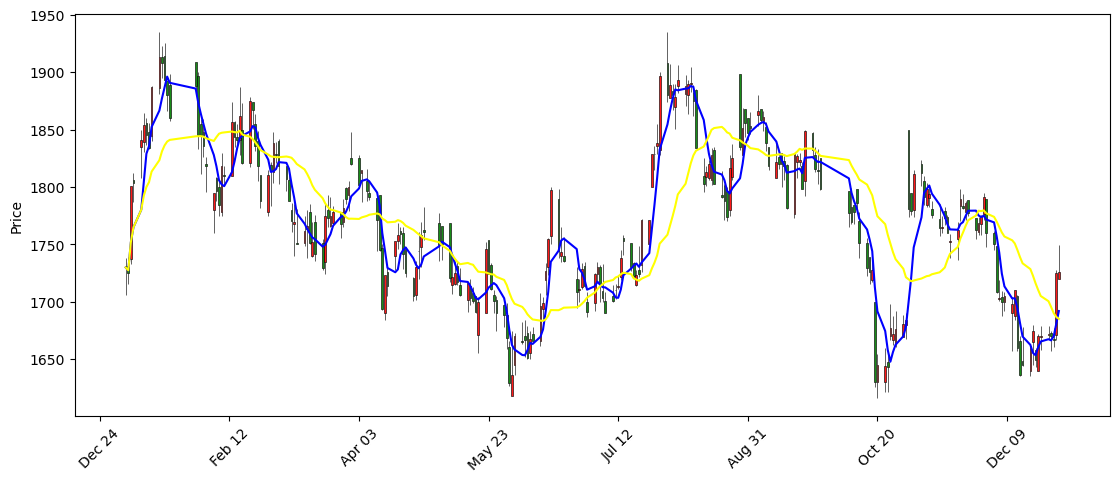

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

# 设置中文显示
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv('C:/Users/86157/Desktop/茅台2023年股价.csv')

# 修改列名并选择需要的列（这里修正了语法错误）
df.columns = ['Date','Open', 'High', 'Low', 'Close','Volume','Amount'] 

# 处理日期格式并设置为索引
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 仅使用Close列计算均线
df['MA5'] = df['Close'].rolling(window=5, min_periods=1).mean()
df['MA20'] = df['Close'].rolling(window=20, min_periods=1).mean()

# 设置K线颜色
market_colors = mpf.make_marketcolors(up='red', down='green')
my_style = mpf.make_mpf_style(marketcolors=market_colors)

# 添加移动平均线（仅基于Close列计算）
add_plots = [
    mpf.make_addplot(df['MA5'], color='blue', width=1.5),
    mpf.make_addplot(df['MA20'], color='yellow', width=1.5)
]

# 绘制K线图（需要OHLC数据）
mpf.plot(
    df,
    type='candle',
    figratio=(10, 4),
    show_nontrading=True,
    addplot=add_plots,
    style=my_style
)
mpf.show()

## 策略规则

In [47]:
import numpy as np
import pandas as pd

# 读取数据
df = pd.read_csv('C:/Users/86157/Desktop/茅台2023年股价.csv')

# 修改列名并选择需要的列
df.columns = ['Date','Open', 'High', 'Low', 'Close','Volume','Amount'] 

# 处理日期格式并设置为索引
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)

# 仅使用Close列计算均线
df['MA5'] = df['Close'].rolling(window=5, min_periods=1).mean()
df['MA20'] = df['Close'].rolling(window=20, min_periods=1).mean()

# 买入信号
def buy_signal(row):
    if row.MA5 > row.MA20:
        return True
    else:
        return False

# 卖出信号
def sell_signal(row):
    if row.MA5 < row.MA20 or row['Close'] < row.MA20 * 0.92:
        return True
    else:
        return False

# 找出所有的信号日期（
buy_dates = df[df.apply(buy_signal, axis=1)].index
sell_dates = df[df.apply(sell_signal, axis=1)].index

print('所有的买入日期:', buy_dates)
print('所有的卖出日期:', sell_dates)

所有的买入日期: DatetimeIndex(['2023-01-10', '2023-01-11', '2023-01-12', '2023-01-13',
               '2023-01-16', '2023-01-17', '2023-01-18', '2023-01-19',
               '2023-01-20', '2023-01-30', '2023-01-31', '2023-02-01',
               '2023-02-02', '2023-02-03', '2023-02-20', '2023-02-21',
               '2023-02-22', '2023-02-23', '2023-02-24', '2023-03-29',
               '2023-03-30', '2023-03-31', '2023-04-03', '2023-04-04',
               '2023-04-06', '2023-04-07', '2023-04-10', '2023-04-11',
               '2023-05-05', '2023-05-08', '2023-06-14', '2023-06-15',
               '2023-06-16', '2023-06-19', '2023-06-20', '2023-06-21',
               '2023-06-26', '2023-06-27', '2023-06-28', '2023-06-29',
               '2023-06-30', '2023-07-03', '2023-07-04', '2023-07-05',
               '2023-07-17', '2023-07-18', '2023-07-19', '2023-07-20',
               '2023-07-21', '2023-07-24', '2023-07-25', '2023-07-26',
               '2023-07-27', '2023-07-28', '2023-07-31', '2023-08-01

## 绘制价格与信号表

In [48]:
df.index

DatetimeIndex(['2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-16',
               ...
               '2023-12-18', '2023-12-19', '2023-12-20', '2023-12-21',
               '2023-12-22', '2023-12-25', '2023-12-26', '2023-12-27',
               '2023-12-28', '2023-12-29'],
              dtype='datetime64[ns]', name='Date', length=242, freq=None)

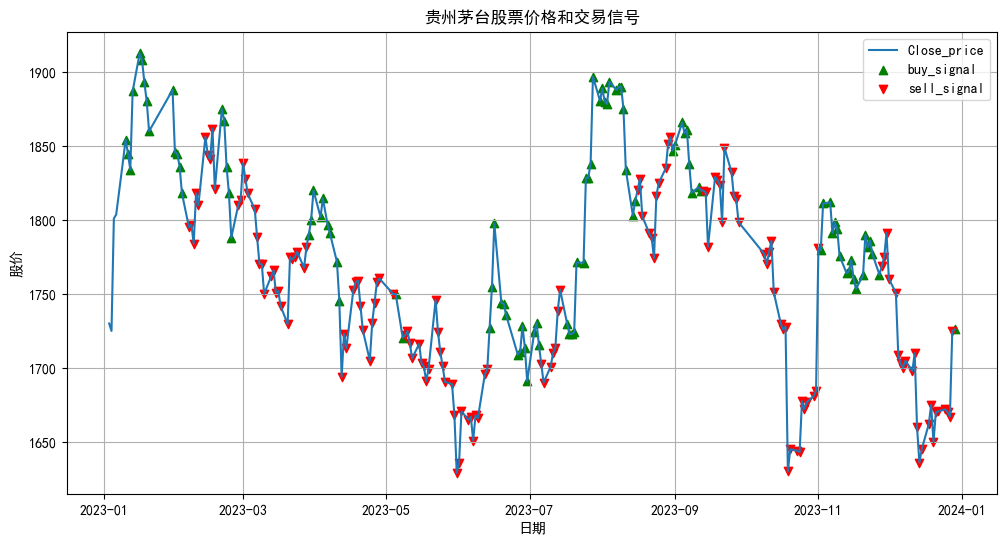

In [52]:
import matplotlib.pyplot as plt
# 设置中文显示
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 绘制图形
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close_price')  # 使用索引作为x轴（日期）

# 绘制买入信号
plt.scatter(buy_dates, df.loc[buy_dates, 'Close'], 
            color='green', marker='^', label='buy_signal')

# 绘制卖出信号
plt.scatter(sell_dates, df.loc[sell_dates, 'Close'], 
            color='red', marker='v', label='sell_signal')

plt.title('贵州茅台股票价格和交易信号')
plt.xlabel('日期')
plt.ylabel('股价')  # 修正了拼写错误
plt.legend()
plt.grid(True)

# 自动调整日期标签的显示格式，避免重叠

plt.show()